# Modelo bidimensional simplificado de escoamento em canal inspirado no Backward-Facing Step via diferenças finitas

## Introdução

A Dinâmica dos Fluidos Computacional (Computational Fluid Dynamics – CFD) constitui uma importante ferramenta para a análise e compreensão de fenômenos de escoamento presentes em diversos problemas de engenharia, como sistemas de transporte de fluidos, máquinas hidráulicas, aerodinâmica e processos industriais. Entre os problemas clássicos de CFD, destaca-se o escoamento em canal com degrau (*Backward-Facing Step* – BFS), amplamente utilizado como benchmark para validação de modelos numéricos devido à presença de fenômenos complexos, como separação da camada limite, recirculação e reanexação do escoamento.

A modelagem completa do problema de BFS é governada pelas equações de Navier-Stokes bidimensionais, cuja resolução numérica exige o emprego de métodos computacionais avançados, como volumes finitos, elementos finitos ou diferenças finitas aplicadas a Equações Diferenciais Parciais (EDPs). Entretanto, para fins didáticos e em conformidade com os objetivos desta atividade, propõe-se a construção de um modelo simplificado, capaz de preservar o contexto físico do problema sem a necessidade de resolver toda a complexidade do escoamento.

Assim, considera-se uma região do canal suficientemente distante da zona de recirculação, na qual o escoamento pode ser aproximado como laminar, permanente, incompressível e totalmente desenvolvido. Sob essas hipóteses, as componentes convectivas tornam-se desprezíveis e o problema reduz-se a uma Equação Diferencial Ordinária (EDO) de segunda ordem que descreve a distribuição de velocidade na direção transversal ao escoamento.

A equação governante simplificada (**Equação de Poisson**) pode ser escrita como:

$$\frac{\partial ^2u}{\partial x^2} + \frac{\partial ^2u}{\partial y^2}=\frac{1}{\mu}\frac{\partial p}{\partial x}$$

ou, de forma equivalente,

$$\frac{\partial ^2u}{\partial x^2} + \frac{\partial ^2u}{\partial y^2}=S_u(x,y)$$

em que (u(y)) representa a velocidade do fluido, ($\mu$) é a viscosidade dinâmica e (C) corresponde a um gradiente de pressão constante.

A resolução dessa EDO será realizada por meio do Método das Diferenças Finitas (MDF), uma das técnicas numéricas mais utilizadas para a discretização de equações diferenciais. O método consiste em substituir as derivadas contínuas por aproximações algébricas obtidas a partir de uma malha discreta do domínio, convertendo o problema diferencial em um sistema de equações lineares passível de solução computacional.

Como etapa complementar, propõe-se a organização do desenvolvimento em um pipeline computacional estruturado, contemplando a formulação física do problema, a discretização numérica, a implementação computacional, a validação por meio da solução analítica e a análise de convergência da solução. Essa abordagem permite não apenas o estudo dos fundamentos de métodos numéricos aplicados à mecânica dos fluidos, mas também estabelece uma ponte conceitual com problemas de maior complexidade, como as simulações CFD do *Backward-Facing Step* e as pesquisas em modelagem computacional baseada em física.

## 1. Definição do Problema Físico

Considera-se uma região simplificada do escoamento após o degrau (*Backward-Facing Step* – BFS), suficientemente distante da zona de recirculação, onde o comportamento do fluido pode ser aproximado por um modelo bidimensional estacionário de difusão. Essa formulação constitui uma evolução do modelo unidimensional anteriormente estudado, permitindo a análise da distribuição espacial da velocidade em duas dimensões.

A equação governante é dada por:

$$
\nabla^2 u = S_u(x,y)
$$

ou, de forma expandida,

$$
\frac{\partial^2 u}{\partial x^2}
+
\frac{\partial^2 u}{\partial y^2}
=

S_u(x,y)
$$

trata-se de uma Equação Diferencial Parcial (EDP) elíptica do tipo Poisson, frequentemente utilizada para modelar fenômenos difusivos em regime estacionário.

O termo fonte é definido como:

$$
S_u(x,y)
=

C\left[
1+\alpha\sin(\pi x)\sin(\pi y)
\right]
$$

Logo, a equação governante pode ser escrita como:

$$
\frac{\partial^2 u}{\partial x^2}
+
\frac{\partial^2 u}{\partial y^2}
=

C\left[
1+\alpha\sin(\pi x)\sin(\pi y)
\right]
$$

onde:

* $S_u(x,y)$ é o termo fonte espacialmente variável;
* $C$ representa a intensidade média da força motriz associada ao gradiente de pressão;
* $\alpha$ é um parâmetro adimensional que controla a amplitude da perturbação;
* $\sin(\pi x)\sin(\pi y)$ introduz uma variação espacial bidimensional no termo fonte, produzindo um campo de velocidades não uniforme.

As condições de contorno adotadas são do tipo Dirichlet homogêneas:

$$
u(0,y)=0,
\qquad
u(L,y)=0,
$$

$$
u(x,0)=0,
\qquad
u(x,H)=0.
$$

Essas condições representam, de forma simplificada, a condição de não deslizamento (*no-slip*) nas fronteiras do domínio bidimensional considerado.

Ressalta-se que essa formulação não corresponde ao problema completo do *Backward-Facing Step*, governado pelas equações de Navier-Stokes bidimensionais. Trata-se de uma aproximação matemática inspirada no contexto do BFS, proposta com o objetivo de estudar a aplicação do Método das Diferenças Finitas em uma EDP bidimensional e analisar suas propriedades de convergência e precisão numérica.

## 2.Escolher parâmetros

Usando C<0 para gerar um perfil positivo de velocidade.

In [4]:
# Bibliotecas
import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from tabulate import tabulate
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata


# Define os caminhos dos diretórios
PATH_DIR = Path.cwd().parent  # diretório atual
PATH_CFD = PATH_DIR / 'bfs2dData/postProcessing' # diretório dos dados CFD
PATH_DATA = PATH_DIR / 'data' # diretório dos dados experimentais
print(PATH_CFD)
print(PATH_DATA)

/home/matheus/Documentos/Mestrado/modelagem_computacional/bfsDifFinitas/bfs2dData/postProcessing
/home/matheus/Documentos/Mestrado/modelagem_computacional/bfsDifFinitas/data


## Visualização dos campos de velocidade e pressão

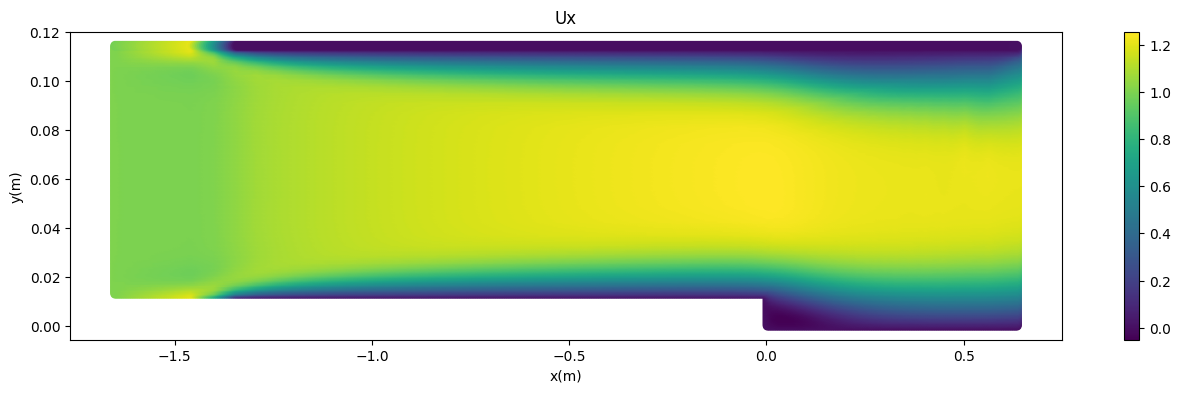

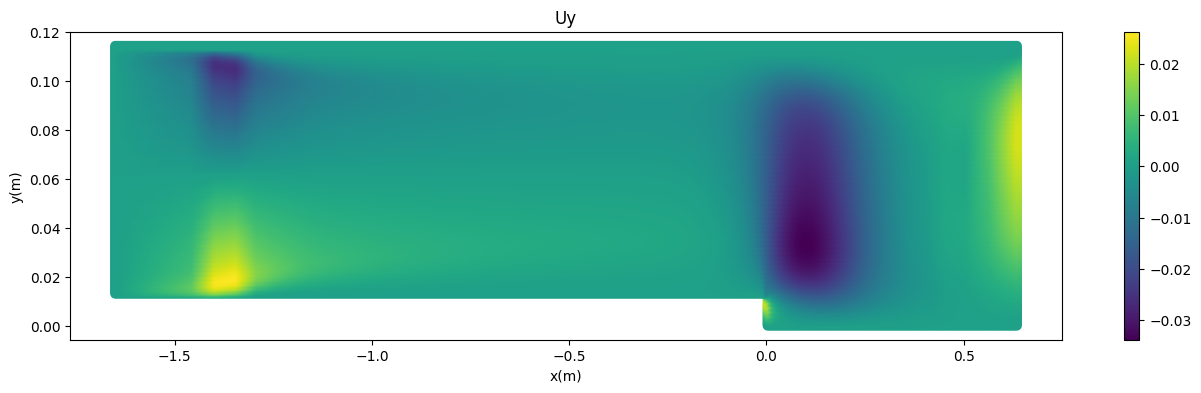

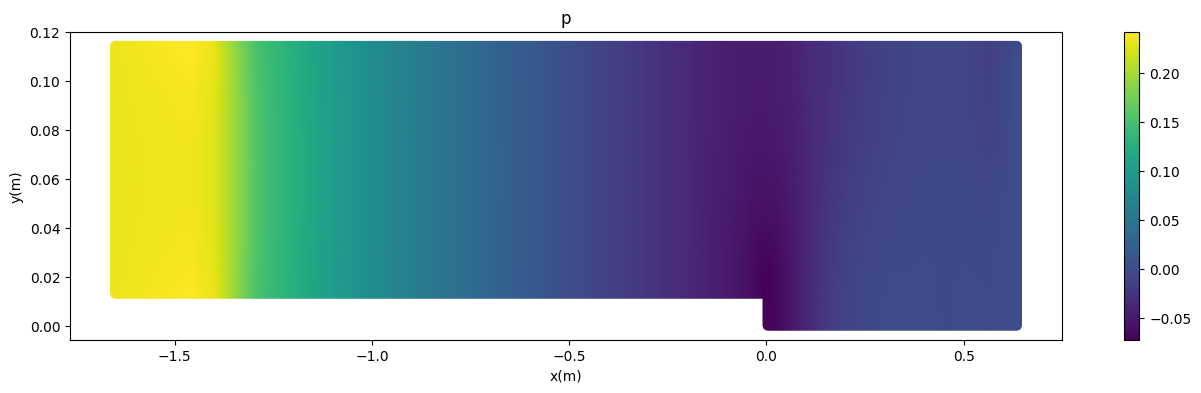

In [5]:
# Visualização dos campos de velocidade e pressão
df = pd.read_csv(PATH_DATA / "dataset_bfs_2d_grid.csv")
x = df["x"].values
y = df["y"].values
Ux = df["Ux"].values
Uy = df["Uy"].values

plt.figure(figsize=(16, 4))
plt.scatter(df["x"], df["y"], c=df["Ux"])
plt.colorbar()
plt.xlabel("x(m)")
plt.ylabel("y(m)")
plt.title("Ux")
plt.show()

plt.figure(figsize=(16, 4))
plt.scatter(df["x"], df["y"], c=df["Uy"])
plt.colorbar()
plt.xlabel("x(m)")
plt.ylabel("y(m)")
plt.title("Uy")
plt.show()

plt.figure(figsize=(16, 4))
plt.scatter(df["x"], df["y"], c=df["p"])
plt.colorbar()
plt.xlabel("x(m)")
plt.ylabel("y(m)")
plt.title("p")
plt.show()

## 3. Montar o sistema linear

Para os pontos internos:

$$\frac{u_{i+1,j} - 2u_{i,j} + u_{i-1,j}}{\Delta x^2} + 
\frac{u_{i+1,j} - 2u_{i,j} + u_{i-1,j}}{\Delta y^2} 
= S_{i,j}$$

## Definindo as matrizes de coeficientes

$$A_w u_{i-1,j} + A_e u_{i+1,j} + A_s u_{i,j-1} + A_n u_{i,j+1} + A_p u_{i,j} = S_{i,j}

In [105]:
# ============================
# Parâmetros
# ============================

precisao = 1e-6
max_iter = 30000
omega = 1.1  # SOR: 1.0 = Gauss-Seidel puro

H = 0.0127

# Usar domínio físico compatível com o CFD
x_min = -1 * H
x_max = 45 * H
y_min = 0.0
y_max = 3 * H

Nx = 240
Ny = 80

x = np.linspace(x_min, x_max, Nx)
y = np.linspace(y_min, y_max, Ny)

dx = x[1] - x[0]
dy = y[1] - y[0]

X, Y = np.meshgrid(x, y, indexing="ij")

# ============================
# Máscara da geometria BFS
# Região sólida antes do degrau:
# x <= 0 e y <= H
# ============================

valid = np.ones((Nx, Ny), dtype=bool)
valid[(X <= 0.0) & (Y <= H)] = False

u = np.zeros((Nx, Ny), dtype=float)

In [111]:
# Recorte do CFD no mesmo domínio do MDF
df_recorte = df[
    (df["x"] >= x_min) &
    (df["x"] <= x_max) &
    (df["y"] >= y_min) &
    (df["y"] <= y_max)
].copy()

# Interpolar pressão do CFD na malha MDF
points_cfd = df_recorte[["x", "y"]].values
p_cfd_values = df_recorte["p"].values

p_grid = griddata(
    points_cfd,
    p_cfd_values,
    (X, Y),
    method="linear"
)

# Preencher NaN usando interpolação nearest
p_grid_nearest = griddata(
    points_cfd,
    p_cfd_values,
    (X, Y),
    method="nearest"
)

p_grid = np.where(np.isnan(p_grid), p_grid_nearest, p_grid)

# Zerar região sólida
p_grid[~valid] = 0.0

# Gradiente de pressão em x
dpdx = np.gradient(p_grid, dx, axis=0)

# Viscosidade cinemática usada no CFD
nu = 5e-05

# Termo fonte da equação simplificada
# d²u/dx² + d²u/dy² = (1/nu) dp/dx
S_grid = -dpdx / nu

# Evitar valores inválidos na região sólida
# Garantir fonte limpa
S_grid = np.nan_to_num(S_grid, nan=0.0, posinf=0.0, neginf=0.0)
S_grid[~valid] = 0.0

print("p_grid NaN:", np.isnan(p_grid).sum())
print("dpdx NaN:", np.isnan(dpdx).sum())
print("S NaN:", np.isnan(S_grid).sum())
print("S min/max:", S_grid[valid].min(), S_grid[valid].max())

p_grid NaN: 0
dpdx NaN: 0
S NaN: 0
S min/max: -12593.93358438891 284635.24211367284


In [107]:
from scipy.ndimage import gaussian_filter
import numpy as np

# Suavizar gradiente de pressão
S_smooth = gaussian_filter(S_grid, sigma=2)

# Considerar apenas região válida
vals = S_smooth[valid]

# Cortar extremos usando percentis
p_low, p_high = np.percentile(vals, [2, 98])

S_clip = np.clip(S_smooth, p_low, p_high)

# Reescalar para uma faixa mais estável numericamente
S_grid = S_clip / np.max(np.abs(S_clip[valid]))

# Ajustar intensidade física/numerica
S0 = -2.0
S_grid = S0 * S_grid

S_grid[~valid] = 0.0

print("Novo S min/max:", S_grid[valid].min(), S_grid[valid].max())

Novo S min/max: -2.0 0.1989778278171324


In [112]:
# ============================
# Coeficientes MDF
# ============================

Aw = 1.0 / dx**2
Ae = 1.0 / dx**2
As = 1.0 / dy**2
An = 1.0 / dy**2
Ap = -2.0 * (1.0 / dx**2 + 1.0 / dy**2)

# ============================
# Iteração MDF 2D
# ============================

for it in range(1, max_iter + 1):

    u_old = u.copy()

    # Região sólida
    u[~valid] = 0.0

    # Contornos externos simplificados
    u[:, 0] = 0.0       # parede inferior
    u[:, -1] = 0.0      # parede superior
    # entrada: gradiente nulo simplificado
    u[0, :] = u[1, :]
    # saída: gradiente nulo
    u[-1, :] = u[-2, :]

    for i in range(1, Nx - 1):
        for j in range(1, Ny - 1):

            if not valid[i, j]:
                continue

            S = S_grid[i, j]

            if not np.isfinite(S):
                S = 0.0

            u_gs = (1.0 / Ap) * (
                S
                - Aw * u[i - 1, j]
                - Ae * u[i + 1, j]
                - As * u[i, j - 1]
                - An * u[i, j + 1]
            )

            # Relaxação SOR
            u[i, j] = (1 - omega) * u[i, j] + omega * u_gs

    erro = np.max(np.abs(u - u_old))

    if it % 50 == 0 or erro < precisao:
        print(f"Iter {it:5d} | erro = {erro:.3e}")

    if erro < precisao:
        print(f"Convergiu em {it} iterações.")
        break

print("U MDF min/max:", u[valid].min(), u[valid].max())

Iter    50 | erro = 5.197e-03
Iter   100 | erro = 2.089e-03
Iter   150 | erro = 1.973e-03
Iter   200 | erro = 1.827e-03
Iter   250 | erro = 1.675e-03
Iter   300 | erro = 1.529e-03
Iter   350 | erro = 1.393e-03
Iter   400 | erro = 1.268e-03
Iter   450 | erro = 1.153e-03
Iter   500 | erro = 1.048e-03
Iter   550 | erro = 9.528e-04
Iter   600 | erro = 8.661e-04
Iter   650 | erro = 7.873e-04
Iter   700 | erro = 7.156e-04
Iter   750 | erro = 6.505e-04
Iter   800 | erro = 5.912e-04
Iter   850 | erro = 5.374e-04
Iter   900 | erro = 4.885e-04
Iter   950 | erro = 4.440e-04
Iter  1000 | erro = 4.035e-04
Iter  1050 | erro = 3.668e-04
Iter  1100 | erro = 3.334e-04
Iter  1150 | erro = 3.030e-04
Iter  1200 | erro = 2.754e-04
Iter  1250 | erro = 2.503e-04
Iter  1300 | erro = 2.275e-04
Iter  1350 | erro = 2.067e-04
Iter  1400 | erro = 1.879e-04
Iter  1450 | erro = 1.708e-04
Iter  1500 | erro = 1.552e-04
Iter  1550 | erro = 1.411e-04
Iter  1600 | erro = 1.282e-04
Iter  1650 | erro = 1.165e-04
Iter  1700

In [113]:
# ============================
# Interpolar CFD na malha MDF
# ============================

df_recorte = df[
    (df["x"] >= x_min) &
    (df["x"] <= x_max) &
    (df["y"] >= y_min) &
    (df["y"] <= y_max)
].copy()

points = df_recorte[["x", "y"]].values
values = df_recorte["Ux"].values

Ux_cfd = griddata(
    points,
    values,
    (X, Y),
    method="linear"
)

mask_comp = valid & ~np.isnan(Ux_cfd)

# ============================
# Normalização para comparar forma
# ============================

u_mdf_norm = u / np.nanmax(np.abs(u[mask_comp]))
u_cfd_norm = Ux_cfd / np.nanmax(np.abs(Ux_cfd[mask_comp]))

erro = u_mdf_norm - u_cfd_norm

MAE = np.mean(np.abs(erro[mask_comp]))
RMSE = np.sqrt(np.mean(erro[mask_comp]**2))
L2_rel = np.linalg.norm(erro[mask_comp]) / np.linalg.norm(u_cfd_norm[mask_comp])
Linf = np.max(np.abs(erro[mask_comp]))

print(f"MAE    = {MAE:.6f}")
print(f"RMSE   = {RMSE:.6f}")
print(f"L2 rel = {L2_rel:.6f}")
print(f"L∞     = {Linf:.6f}")

MAE    = 0.491332
RMSE   = 0.579772
L2 rel = 0.893129
L∞     = 1.003988


## Plotagem do gráfico de intensidade da componente horizontal da velocidade ($u(x,y)$)

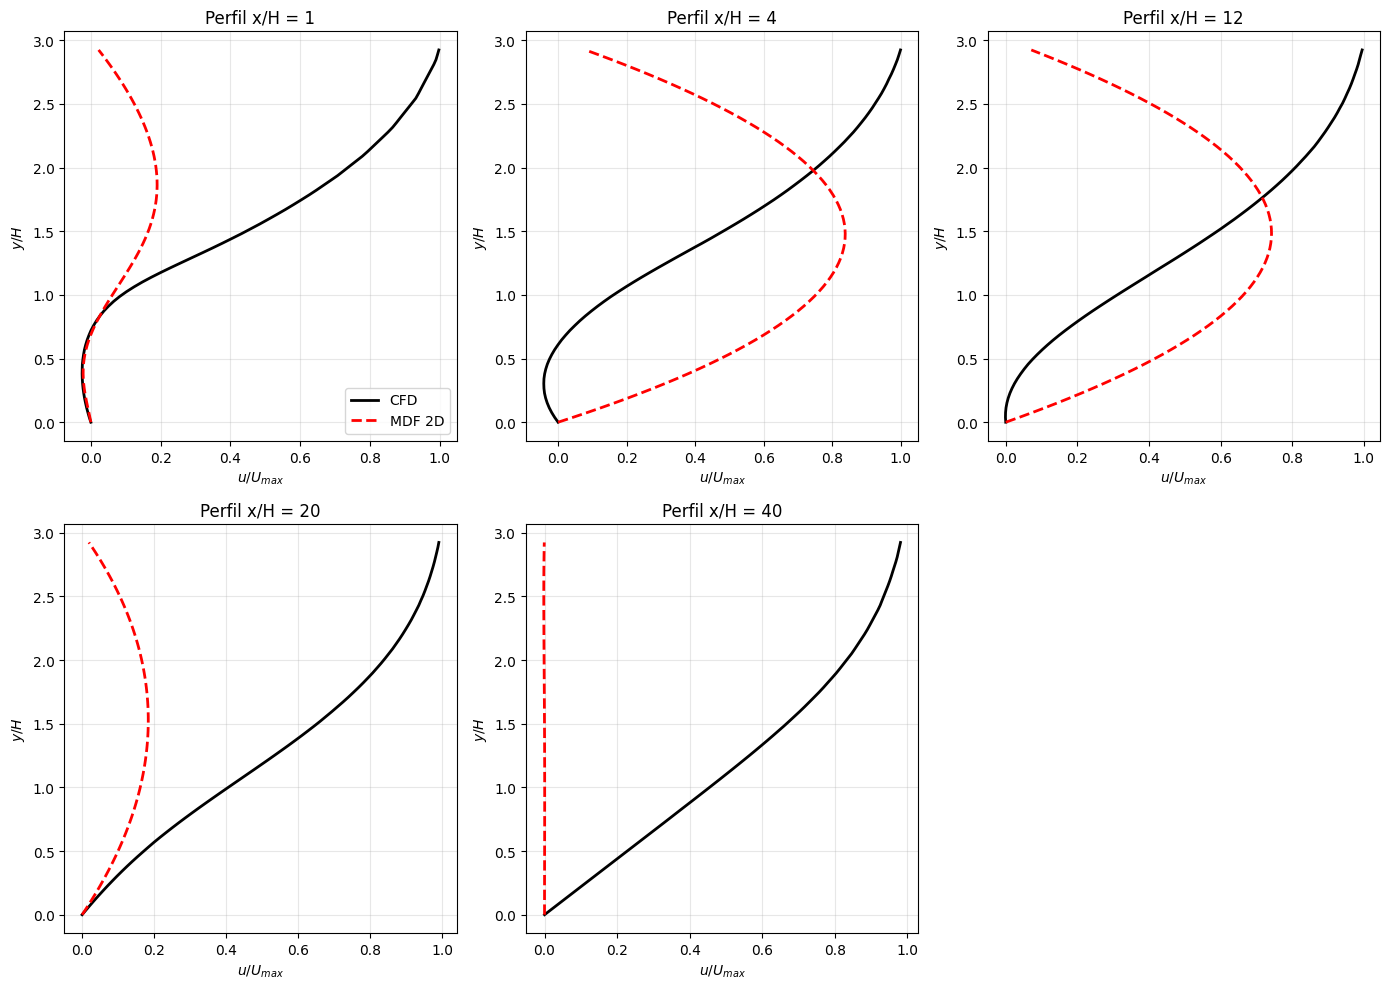

In [114]:
import numpy as np
import matplotlib.pyplot as plt

perfis = [1, 4, 12, 20, 40]

def extrair_perfil_mdf_cfd(xh, X, Y, u_mdf, Ux_cfd, mask_comp, H):
    x_alvo = xh * H

    # índice da coluna mais próxima
    i = np.argmin(np.abs(X[:, 0] - x_alvo))

    y_col = Y[i, :]
    mdf_col = u_mdf[i, :]
    cfd_col = Ux_cfd[i, :]
    mask_col = mask_comp[i, :]

    y_col = y_col[mask_col]
    mdf_col = mdf_col[mask_col]
    cfd_col = cfd_col[mask_col]

    # ordena por y
    idx = np.argsort(y_col)

    return y_col[idx], mdf_col[idx], cfd_col[idx]


# ============================
# Normalização global
# ============================

u_mdf_norm = u / np.nanmax(np.abs(u[mask_comp]))
u_cfd_norm = Ux_cfd / np.nanmax(np.abs(Ux_cfd[mask_comp]))

# ============================
# Comparação por perfil
# ============================

metricas_perfis = []

plt.figure(figsize=(14, 10))

for k, xh in enumerate(perfis, start=1):

    y_prof, u_mdf_prof, u_cfd_prof = extrair_perfil_mdf_cfd(
        xh=xh,
        X=X,
        Y=Y,
        u_mdf=u_mdf_norm,
        Ux_cfd=u_cfd_norm,
        mask_comp=mask_comp,
        H=H
    )

    erro = u_mdf_prof - u_cfd_prof

    MAE = np.mean(np.abs(erro))
    RMSE = np.sqrt(np.mean(erro**2))
    L2_rel = np.linalg.norm(erro) / np.linalg.norm(u_cfd_prof)
    Linf = np.max(np.abs(erro))

    metricas_perfis.append({
        "x/H": xh,
        "MAE": MAE,
        "RMSE": RMSE,
        "L2_rel": L2_rel,
        "Linf": Linf
    })

    plt.subplot(2, 3, k)
    plt.plot(u_cfd_prof, y_prof / H, "k-", linewidth=2, label="CFD")
    plt.plot(u_mdf_prof, y_prof / H, "r--", linewidth=2, label="MDF 2D")

    plt.title(f"Perfil x/H = {xh}")
    plt.xlabel(r"$u/U_{max}$")
    plt.ylabel(r"$y/H$")
    plt.grid(True, alpha=0.3)

    if k == 1:
        plt.legend()

plt.tight_layout()
plt.show()

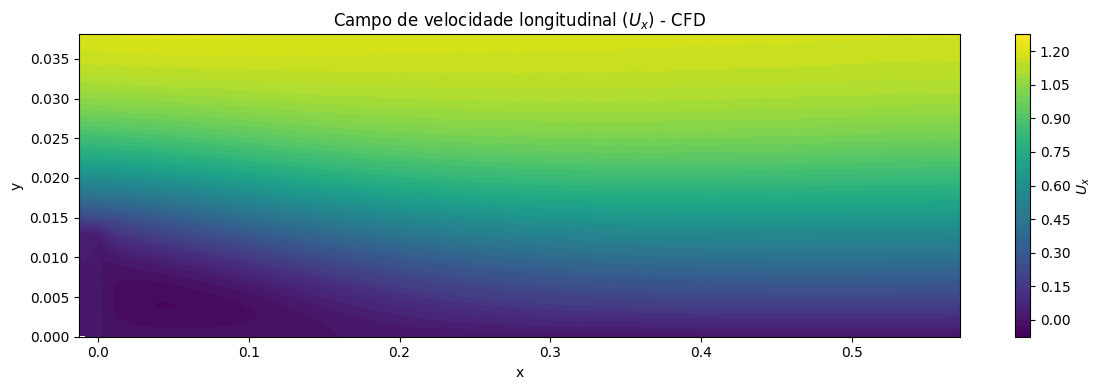

In [118]:
plt.figure(figsize=(12, 4))

cont = plt.tricontourf(
    df["x"],
    df["y"],
    df["Ux"],
    levels=60,
    cmap="viridis"
)

plt.colorbar(cont, label=r"$U_x$")

plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Campo de velocidade longitudinal ($U_x$) - CFD")

plt.xlim(-1*H, 45*H)
plt.ylim(0, 3*H)

plt.tight_layout()
plt.show()

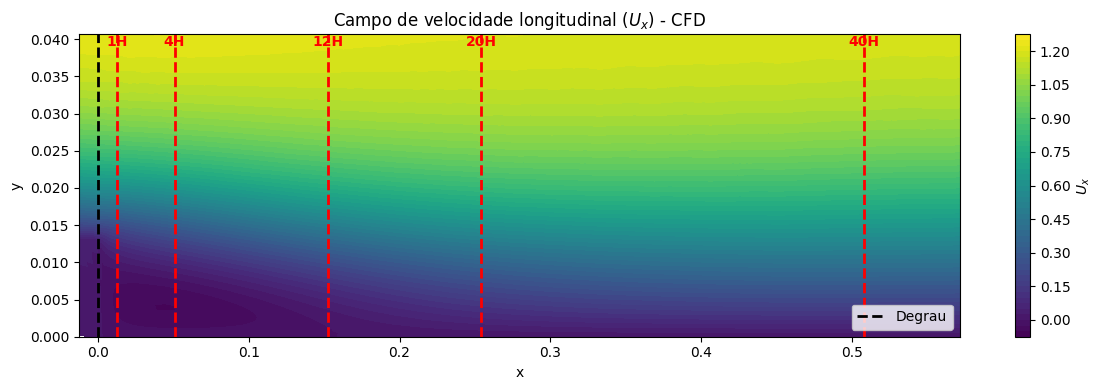

In [119]:
perfis = [1, 4, 12, 20, 40]

plt.figure(figsize=(12, 4))

cont = plt.tricontourf(
    df["x"],
    df["y"],
    df["Ux"],
    levels=60,
    cmap="viridis"
)

plt.colorbar(cont, label=r"$U_x$")

for xh in perfis:
    xpos = xh * H

    plt.axvline(
        xpos,
        color="red",
        linestyle="--",
        linewidth=2
    )

    plt.text(
        xpos,
        3.05*H,
        f"{xh}H",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="red"
    )

plt.axvline(0, color="black", linestyle="--", linewidth=2, label="Degrau")

plt.xlim(-1*H, 45*H)
plt.ylim(0, 3.2*H)

plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Campo de velocidade longitudinal ($U_x$) - CFD")

plt.legend()
plt.tight_layout()
plt.show()

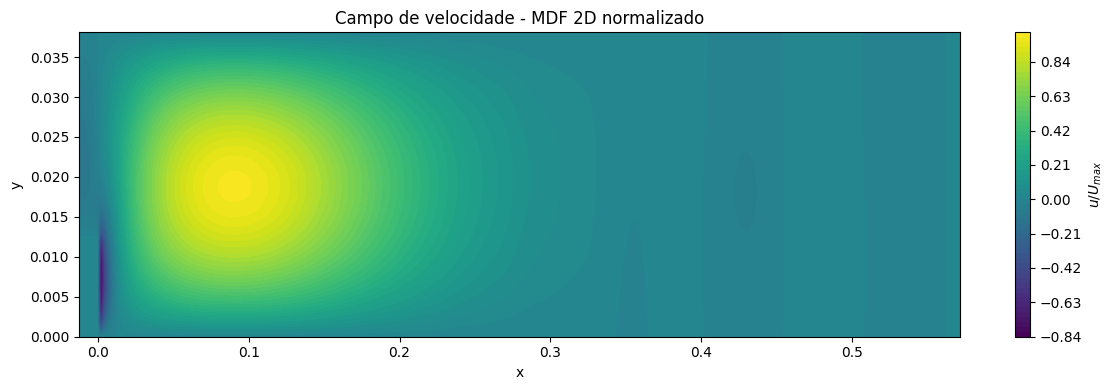

In [117]:
plt.figure(figsize=(12, 4))

cont = plt.tricontourf(
    X.ravel(),
    Y.ravel(),
    u_mdf_norm.ravel(),
    levels=60,
    cmap="viridis"
)

plt.colorbar(cont, label=r"$u/U_{max}$")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Campo de velocidade - MDF 2D normalizado")

plt.xlim(-1*H, 45*H)
plt.ylim(0, 3*H)

plt.tight_layout()
plt.show()

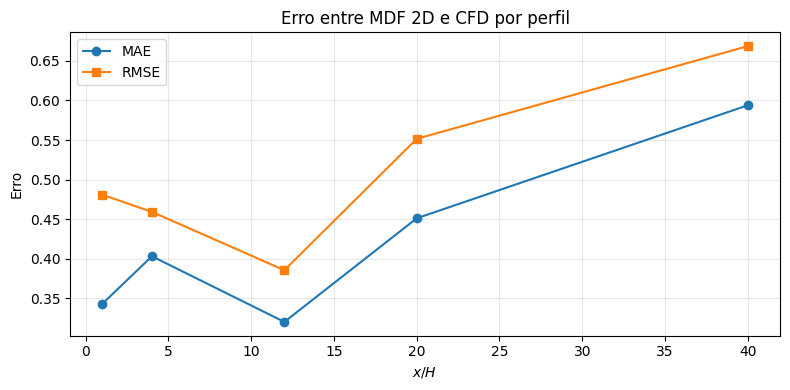

In [115]:

df_metricas_perfis = pd.DataFrame(metricas_perfis)

plt.figure(figsize=(8, 4))

plt.plot(
    df_metricas_perfis["x/H"],
    df_metricas_perfis["MAE"],
    marker="o",
    label="MAE"
)

plt.plot(
    df_metricas_perfis["x/H"],
    df_metricas_perfis["RMSE"],
    marker="s",
    label="RMSE"
)

plt.xlabel(r"$x/H$")
plt.ylabel("Erro")
plt.title("Erro entre MDF 2D e CFD por perfil")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

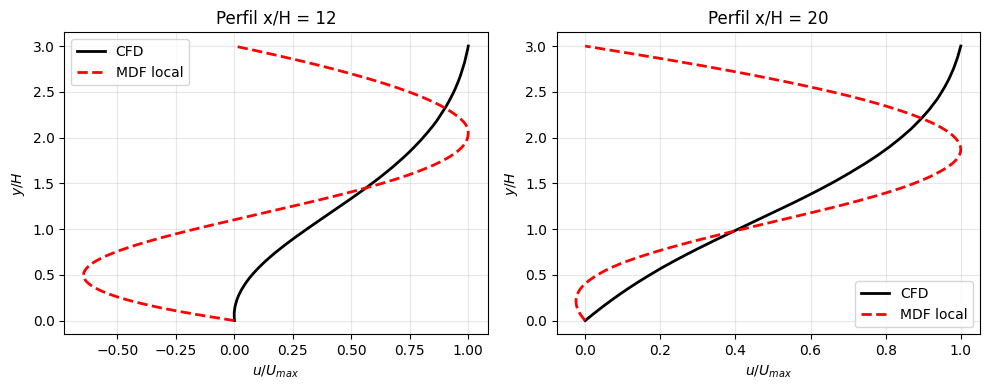

,x/H,MAE,RMSE,L2_rel,Linf
0,12,0.360528,0.444548,0.691901,1.0
1,20,0.211802,0.304335,0.451109,1.0


In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.linalg import solve_banded

# ============================
# Configurações
# ============================

perfis = [12, 20]   # regiões afastadas
nu = 1e-5           # viscosidade cinemática do CFD
Ny = 200

# domínio vertical
y_min = 0.0
y_max = 3 * H
y_grid = np.linspace(y_min, y_max, Ny)
dy = y_grid[1] - y_grid[0]

metricas = []

# ============================
# Função auxiliar
# ============================

def resolver_edo_y(S, dy):
    """
    Resolve d²u/dy² = S(y)
    com u(0)=0 e u(Hmax)=0
    """

    N = len(S)
    n_int = N - 2

    # matriz tridiagonal em forma banded
    ab = np.zeros((3, n_int))

    ab[0, 1:] = 1.0 / dy**2      # diagonal superior
    ab[1, :]  = -2.0 / dy**2     # diagonal principal
    ab[2, :-1] = 1.0 / dy**2     # diagonal inferior

    b = S[1:-1]

    u_int = solve_banded((1, 1), ab, b)

    u = np.zeros(N)
    u[1:-1] = u_int

    return u


# ============================
# Comparação por perfil
# ============================

plt.figure(figsize=(10, 4))

for k, xh in enumerate(perfis, start=1):

    x_alvo = xh * H

    # janela pequena ao redor do perfil
    tol = 0.25 * H

    df_prof = df[
        (df["x"] >= x_alvo - tol) &
        (df["x"] <= x_alvo + tol) &
        (df["y"] >= y_min) &
        (df["y"] <= y_max)
    ].copy()

    # pontos para interpolação
    points = df[["x", "y"]].values

    # interpolar Ux e p no perfil
    Ux_prof = griddata(
        points,
        df["Ux"].values,
        (np.full_like(y_grid, x_alvo), y_grid),
        method="linear"
    )

    p_prof = griddata(
        points,
        df["p"].values,
        (np.full_like(y_grid, x_alvo), y_grid),
        method="linear"
    )

    # preencher NaNs com nearest
    Ux_near = griddata(
        points,
        df["Ux"].values,
        (np.full_like(y_grid, x_alvo), y_grid),
        method="nearest"
    )

    p_near = griddata(
        points,
        df["p"].values,
        (np.full_like(y_grid, x_alvo), y_grid),
        method="nearest"
    )

    Ux_prof = np.where(np.isnan(Ux_prof), Ux_near, Ux_prof)
    p_prof = np.where(np.isnan(p_prof), p_near, p_prof)

    # segunda derivada em y
    dUx_dy = np.gradient(Ux_prof, dy)

    # termo fonte
    S = np.gradient(dUx_dy, dy)

    # suavização simples do termo fonte
    S = pd.Series(S).rolling(window=9, center=True, min_periods=1).mean().values

    # normalizar fonte para comparação de forma
    S = S / np.max(np.abs(S))

    # resolver MDF 1D local
    u_mdf = resolver_edo_y(S, dy)

    # normalizar velocidades
    Ux_cfd_norm = Ux_prof / np.max(np.abs(Ux_prof))
    u_mdf_norm = u_mdf / np.max(np.abs(u_mdf))

    # corrigir sinal se necessário
    if np.corrcoef(Ux_cfd_norm, u_mdf_norm)[0, 1] < 0:
        u_mdf_norm = -u_mdf_norm

    # métricas
    erro = u_mdf_norm - Ux_cfd_norm

    MAE = np.mean(np.abs(erro))
    RMSE = np.sqrt(np.mean(erro**2))
    L2_rel = np.linalg.norm(erro) / np.linalg.norm(Ux_cfd_norm)
    Linf = np.max(np.abs(erro))

    metricas.append({
        "x/H": xh,
        "MAE": MAE,
        "RMSE": RMSE,
        "L2_rel": L2_rel,
        "Linf": Linf
    })

    # plot
    plt.subplot(1, 2, k)

    plt.plot(
        Ux_cfd_norm,
        y_grid / H,
        "k-",
        linewidth=2,
        label="CFD"
    )

    plt.plot(
        u_mdf_norm,
        y_grid / H,
        "r--",
        linewidth=2,
        label="MDF local"
    )

    plt.title(f"Perfil x/H = {xh}")
    plt.xlabel(r"$u/U_{max}$")
    plt.ylabel(r"$y/H$")
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

# ============================
# Métricas
# ============================

df_metricas = pd.DataFrame(metricas)
df_metricas

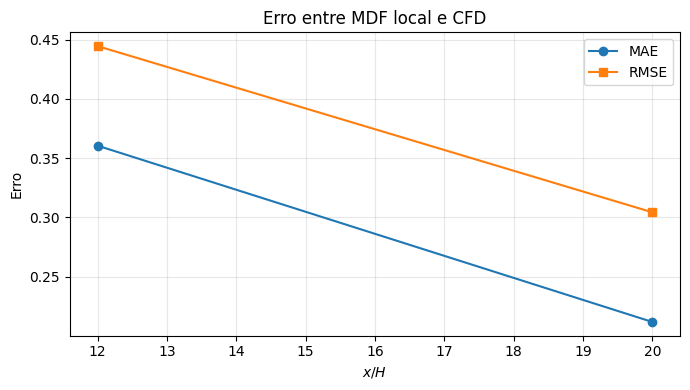

In [127]:
plt.figure(figsize=(7, 4))

plt.plot(
    df_metricas["x/H"],
    df_metricas["MAE"],
    marker="o",
    label="MAE"
)

plt.plot(
    df_metricas["x/H"],
    df_metricas["RMSE"],
    marker="s",
    label="RMSE"
)

plt.xlabel(r"$x/H$")
plt.ylabel("Erro")
plt.title("Erro entre MDF local e CFD")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

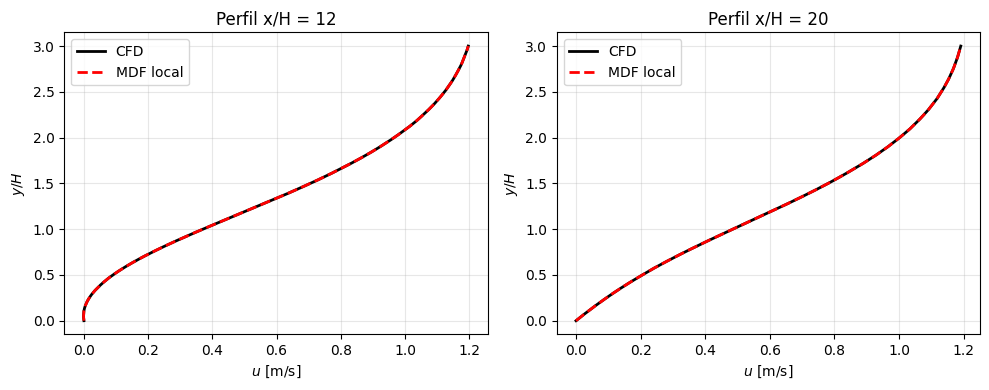

,x/H,MAE,RMSE,L2_rel,Linf
0,12,4.902401e-15,5.488890e-15,7.137542e-15,9.214851e-15
1,20,5.223981e-15,6.002087e-15,7.471012e-15,1.054712e-14


In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.linalg import solve_banded

# ============================
# Configurações
# ============================

perfis = [12, 20]
Ny = 200

y_min = 0.0
y_max = 3 * H

y_grid = np.linspace(y_min, y_max, Ny)
dy = y_grid[1] - y_grid[0]

points = df[["x", "y"]].values

metricas = []


# ============================
# Resolver d²u/dy² = S
# com condições de contorno do CFD
# ============================

def resolver_edo_y_bc_cfd(S, dy, u0, uL):
    """
    Resolve:
        d²u/dy² = S(y)

    com:
        u(0) = u0
        u(L) = uL
    """

    N = len(S)
    n_int = N - 2

    ab = np.zeros((3, n_int))

    # diagonal superior
    ab[0, 1:] = 1.0 / dy**2

    # diagonal principal
    ab[1, :] = -2.0 / dy**2

    # diagonal inferior
    ab[2, :-1] = 1.0 / dy**2

    b = S[1:-1].copy()

    # contribuição das condições de contorno
    b[0] -= u0 / dy**2
    b[-1] -= uL / dy**2

    u_int = solve_banded((1, 1), ab, b)

    u = np.zeros(N)
    u[0] = u0
    u[-1] = uL
    u[1:-1] = u_int

    return u


# ============================
# Comparação por perfil
# ============================

plt.figure(figsize=(10, 4))

for k, xh in enumerate(perfis, start=1):

    x_alvo = xh * H
    x_line = np.full_like(y_grid, x_alvo)

    # ============================
    # Interpolar Ux do CFD no perfil
    # ============================

    Ux_prof = griddata(
        points,
        df["Ux"].values,
        (x_line, y_grid),
        method="linear"
    )

    Ux_near = griddata(
        points,
        df["Ux"].values,
        (x_line, y_grid),
        method="nearest"
    )

    Ux_prof = np.where(np.isnan(Ux_prof), Ux_near, Ux_prof)

    # ============================
    # Calcular S = d²Ux/dy²
    # usando diferença central
    # ============================

    S = np.zeros_like(Ux_prof)

    S[1:-1] = (
        Ux_prof[:-2]
        - 2.0 * Ux_prof[1:-1]
        + Ux_prof[2:]
    ) / dy**2

    S[0] = S[1]
    S[-1] = S[-2]

    # ============================
    # Condições de contorno vindas do CFD
    # ============================

    u0 = Ux_prof[0]
    uL = Ux_prof[-1]

    # ============================
    # Resolver MDF local
    # ============================

    u_mdf = resolver_edo_y_bc_cfd(S, dy, u0, uL)

    # ============================
    # Métricas sem normalizar
    # ============================

    erro = u_mdf - Ux_prof

    MAE = np.mean(np.abs(erro))
    RMSE = np.sqrt(np.mean(erro**2))
    L2_rel = np.linalg.norm(erro) / np.linalg.norm(Ux_prof)
    Linf = np.max(np.abs(erro))

    metricas.append({
        "x/H": xh,
        "MAE": MAE,
        "RMSE": RMSE,
        "L2_rel": L2_rel,
        "Linf": Linf
    })

    # ============================
    # Plot
    # ============================

    plt.subplot(1, 2, k)

    plt.plot(
        Ux_prof,
        y_grid / H,
        "k-",
        linewidth=2,
        label="CFD"
    )

    plt.plot(
        u_mdf,
        y_grid / H,
        "r--",
        linewidth=2,
        label="MDF local"
    )

    plt.title(f"Perfil x/H = {xh}")
    plt.xlabel(r"$u$ [m/s]")
    plt.ylabel(r"$y/H$")
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()


# ============================
# Tabela de métricas
# ============================

df_metricas_laplaciano = pd.DataFrame(metricas)
df_metricas_laplaciano

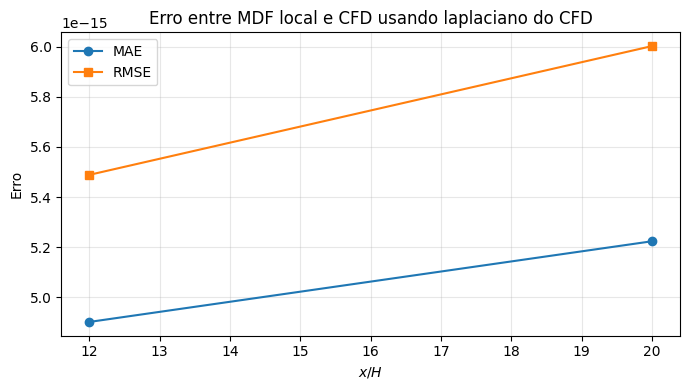

In [129]:
plt.figure(figsize=(7, 4))

plt.plot(
    df_metricas_laplaciano["x/H"],
    df_metricas_laplaciano["MAE"],
    marker="o",
    label="MAE"
)

plt.plot(
    df_metricas_laplaciano["x/H"],
    df_metricas_laplaciano["RMSE"],
    marker="s",
    label="RMSE"
)

plt.xlabel(r"$x/H$")
plt.ylabel("Erro")
plt.title("Erro entre MDF local e CFD usando laplaciano do CFD")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()